In [8]:
import pandas as pd
import numpy as np
import json
import os
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [9]:
import os
import json
data_path = r"Mini_Project_Sem2"

matches = []

for file in os.listdir(data_path):
    if file.endswith(".json"):
        with open(os.path.join(data_path, file), 'r') as f:
            matches.append(json.load(f))

print("Total matches loaded:", len(matches))

Total matches loaded: 1127


In [47]:
records = []

for i, match in enumerate(matches):
    
    try:
        match_id = i
        
        # Extract match-level info INSIDE loop
        info = match.get("info", {})
        
        teams = info.get("teams", [None, None])
        team1, team2 = teams[0], teams[1]
        
        venue = info.get("venue", "Unknown")
        date = info.get("dates", ["Unknown"])[0]
        
        innings = match.get("innings", [])
        
        for inning in innings:
            batting_team = inning.get("team")
            
            # opponent logic
            opponent = team2 if batting_team == team1 else team1
            
            for over in inning.get("overs", []):
                for ball in over.get("deliveries", []):
                    
                    batter = ball.get("batter")
                    runs = ball.get("runs", {}).get("batter", 0)
                    
                    if batter is None:
                        continue
                    
                    records.append({
                        "match_id": match_id,
                        "batter": batter,
                        "runs": runs,
                        "ball": 1,
                        "date": date,        
                        "opponent": opponent, 
                        "venue": venue        
                    })
                    
    except Exception as e:
        print("Error in match:", i)
        continue

df = pd.DataFrame(records)

In [11]:
print(df.shape)
print(df.head())

(251290, 4)
   match_id         batter  runs  ball
0         3       AP Yadav     0     1
1         3       AP Yadav     0     1
2         3       AP Yadav     1     1
3         3  C Chatphaisan     0     1
4         3  C Chatphaisan     0     1


In [49]:
player_match_stats = df.groupby(
    ["match_id", "batter", "opponent", "venue", "date"]
).agg({
    "runs": "sum",
    "ball": "sum"
}).reset_index()

player_match_stats["strike_rate"] = (
    player_match_stats["runs"] / player_match_stats["ball"]
) * 100
print(player_match_stats.head())

   match_id         batter      opponent                             venue  \
0         0       AP Yadav  Saudi Arabia  Terdthai Cricket Ground, Bangkok   
1         0     AV Lazarus  Saudi Arabia  Terdthai Cricket Ground, Bangkok   
2         0   Abdul Waheed      Thailand  Terdthai Cricket Ground, Bangkok   
3         0  C Chatphaisan  Saudi Arabia  Terdthai Cricket Ground, Bangkok   
4         0    C Pengkumta  Saudi Arabia  Terdthai Cricket Ground, Bangkok   

         date  runs  ball  strike_rate  
0  2024-02-13     2    10    20.000000  
1  2024-02-13    51    39   130.769231  
2  2024-02-13    58    40   145.000000  
3  2024-02-13     3     9    33.333333  
4  2024-02-13     3     3   100.000000  


In [34]:
date = match.get("info", {}).get("dates", ["Unknown"])[0]

In [13]:
date = match.get("info", {}).get("dates", ["Unknown"])[0]

records.append({
    "match_id": match_id,
    "batter": batter,
    "runs": runs,
    "ball": 1,
    "date": date
})

In [14]:
print(df.columns)

Index(['match_id', 'batter', 'runs', 'ball'], dtype='str')


In [15]:
player_match_stats = player_match_stats.sort_values(
    by=["batter", "match_id"]
)

In [16]:
player_match_stats["prev_runs"] = (
    player_match_stats.groupby("batter")["runs"].shift(1)
)

player_match_stats["prev_sr"] = (
    player_match_stats.groupby("batter")["strike_rate"].shift(1)
)

In [17]:
player_match_stats["avg_last_3"] = (
    player_match_stats.groupby("batter")["runs"]
    .rolling(3)
    .mean()
    .reset_index(0, drop=True)
)

In [18]:
player_match_stats["avg_last_5"] = (
    player_match_stats.groupby("batter")["runs"]
    .rolling(5)
    .mean()
    .reset_index(0, drop=True)
)

In [19]:
player_match_stats = player_match_stats.dropna()

In [20]:
print(player_match_stats.head())

       match_id       batter  runs  ball  strike_rate  prev_runs     prev_sr  \
5800          6  A Alexander     1     4    25.000000       30.0  300.000000   
7916         10  A Alexander     5     2   250.000000        1.0   25.000000   
4874          5   A Athanaze     1     4    25.000000       21.0  105.000000   
12554       925   A Augastin    11    14    78.571429       56.0  127.272727   
12617       929   A Augastin     4     6    66.666667       11.0   78.571429   

       avg_last_3  avg_last_5  
5800    10.333333         9.0  
7916    12.000000         7.6  
4874    40.333333        65.2  
12554   28.666667        33.2  
12617   23.666667        30.2  


In [21]:
features = ["prev_runs", "prev_sr", "avg_last_3"]

X = player_match_stats[features]
y = player_match_stats["runs"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4345, 3)
Test size: (1087, 3)


In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 11.754693210058244
R2 Score: 0.5019444291506885


In [25]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

      Feature  Importance
2  avg_last_3    0.705739
0   prev_runs    0.168666
1     prev_sr    0.125595


In [26]:
sample = pd.DataFrame({
    "prev_runs": [35],
    "prev_sr": [140],
    "avg_last_3": [30]
})

prediction = model.predict(sample)

print("Predicted Runs:", prediction[0])

Predicted Runs: 21.962779142205637


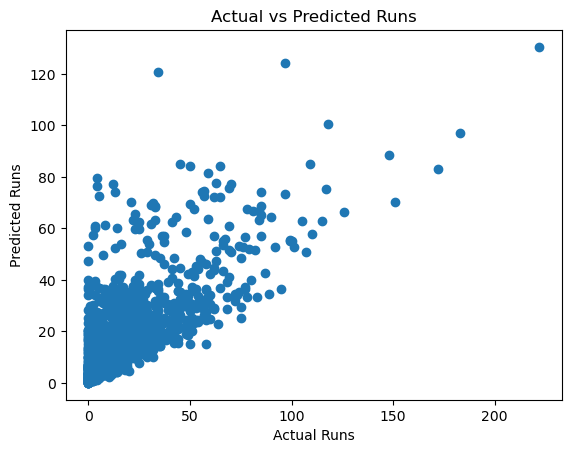

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted Runs")
plt.show()

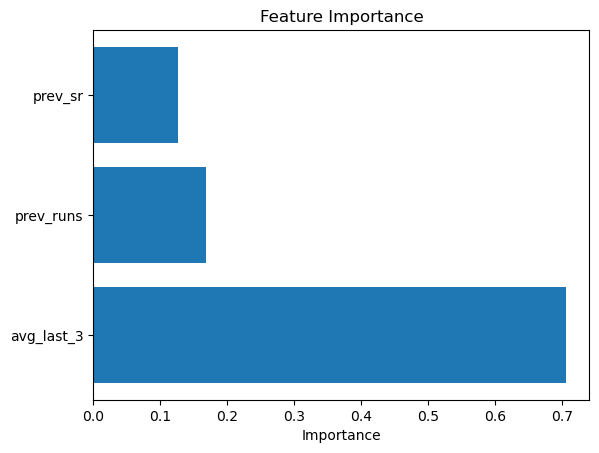

In [28]:
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

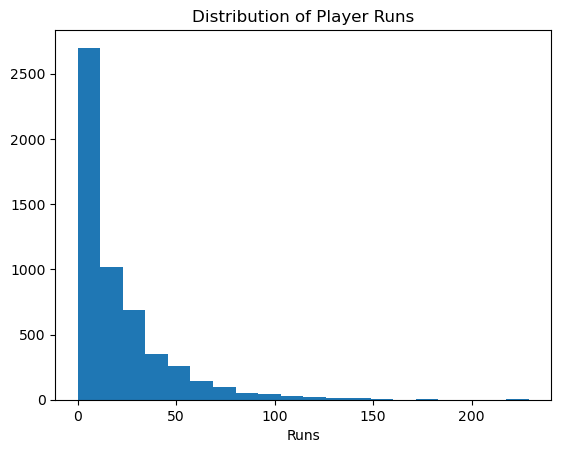

In [29]:
plt.hist(player_match_stats["runs"], bins=20)
plt.xlabel("Runs")
plt.title("Distribution of Player Runs")
plt.show()

In [30]:
print(df.columns)

Index(['match_id', 'batter', 'runs', 'ball'], dtype='str')


In [31]:
team1 = match.get("info", {}).get("teams", [None, None])[0]
team2 = match.get("info", {}).get("teams", [None, None])[1]

venue = match.get("info", {}).get("venue", "Unknown")
date = match.get("info", {}).get("dates", ["Unknown"])[0]

In [32]:
batting_team = inning.get("team")

if batting_team == team1:
    opponent = team2
else:
    opponent = team1

In [33]:
records.append({
    "match_id": match_id,
    "batter": batter,
    "runs": runs,
    "ball": 1,
    "date": date,
    "opponent": opponent,  
    "venue": venue
})

In [34]:
df = pd.DataFrame(records)

In [35]:
print(df.columns)

Index(['match_id', 'batter', 'runs', 'ball', 'date', 'opponent', 'venue'], dtype='str')


In [36]:
player_match_stats = df.groupby(
    ["match_id", "batter", "opponent", "venue", "date"]
).agg({
    "runs": "sum",
    "ball": "sum"
}).reset_index()

In [37]:
from sklearn.preprocessing import LabelEncoder

le_opponent = LabelEncoder()
player_match_stats["opponent_encoded"] = le_opponent.fit_transform(
    player_match_stats["opponent"]
)

In [38]:
venue = match.get("info", {}).get("venue", "Unknown")

In [39]:
le_venue = LabelEncoder()
player_match_stats["venue_encoded"] = le_venue.fit_transform(
    player_match_stats["venue"]
)

In [40]:
def pressure_label(runs):
    if runs < 20:
        return 0   # low pressure
    elif runs < 50:
        return 1   # medium
    else:
        return 2   # high pressure

player_match_stats["pressure"] = player_match_stats["runs"].apply(pressure_label)

In [41]:
def classify_innings(runs):
    if runs < 20:
        return "Bad"
    elif runs < 50:
        return "Average"
    else:
        return "Good"

player_match_stats["innings_class"] = player_match_stats["runs"].apply(classify_innings)

In [42]:
le_class = LabelEncoder()
player_match_stats["innings_class_encoded"] = le_class.fit_transform(
    player_match_stats["innings_class"]
)

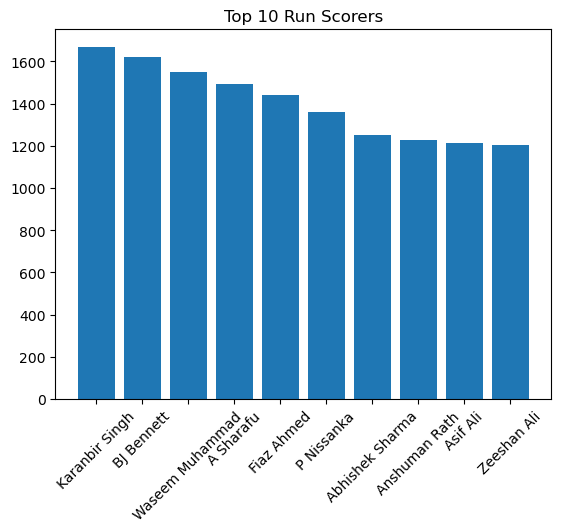

In [50]:
top_players = (
    player_match_stats
    .groupby("batter")["runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
plt.bar(top_players.index, top_players.values)
plt.xticks(rotation=45)
plt.title("Top 10 Run Scorers")
plt.show()

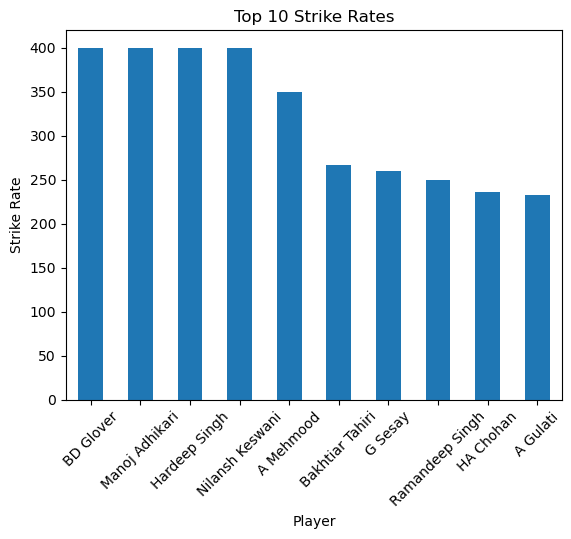

In [51]:
sr = player_match_stats.groupby("batter")["strike_rate"].mean().sort_values(ascending=False).head(10)

plt.figure()
sr.plot(kind="bar")
plt.title("Top 10 Strike Rates")
plt.xlabel("Player")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)
plt.show()

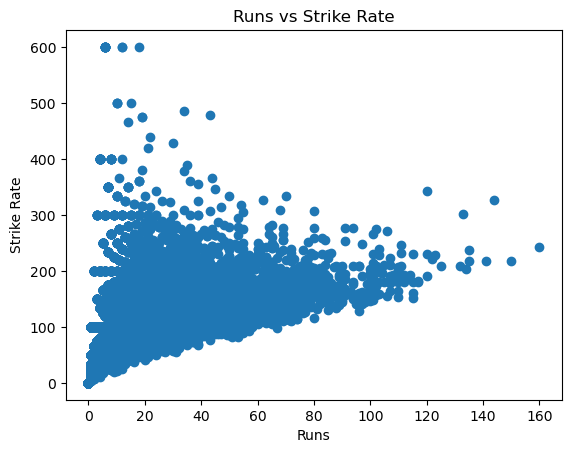

In [52]:
plt.figure()
plt.scatter(player_match_stats["runs"], player_match_stats["strike_rate"])
plt.xlabel("Runs")
plt.ylabel("Strike Rate")
plt.title("Runs vs Strike Rate")
plt.show()

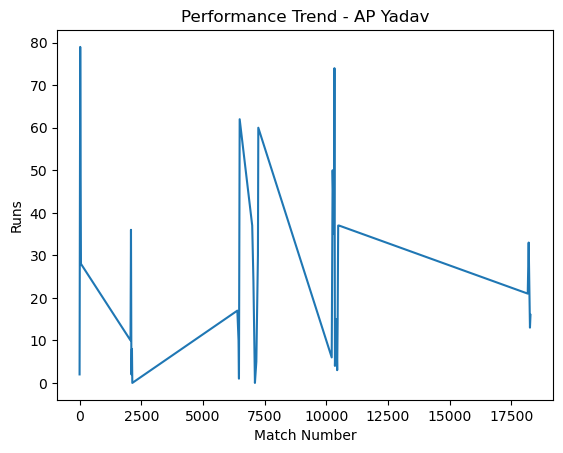

In [53]:
player_name = player_match_stats["batter"].iloc[0]

player_data = player_match_stats[player_match_stats["batter"] == player_name]

plt.figure()
plt.plot(player_data["runs"])
plt.title(f"Performance Trend - {player_name}")
plt.xlabel("Match Number")
plt.ylabel("Runs")
plt.show()

<Figure size 640x480 with 0 Axes>

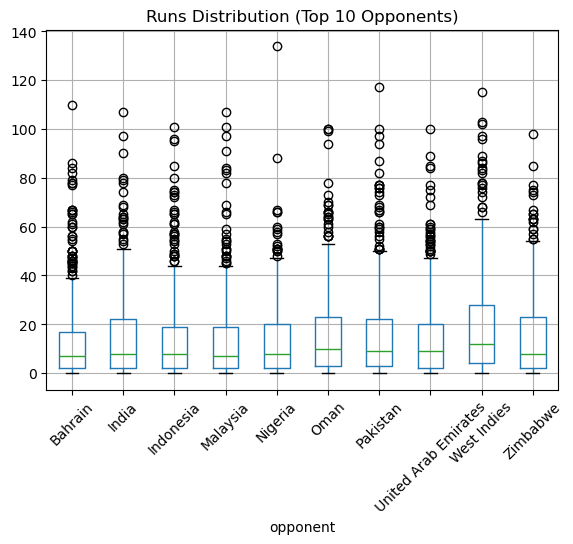

In [59]:
# Select top 10 opponents by number of matches
top_opponents = (
    player_match_stats["opponent"]
    .value_counts()
    .head(10)
    .index
)

filtered_df = player_match_stats[
    player_match_stats["opponent"].isin(top_opponents)
]

plt.figure()
filtered_df.boxplot(column="runs", by="opponent")
plt.xticks(rotation=45)
plt.title("Runs Distribution (Top 10 Opponents)")
plt.suptitle("")  # removes extra title
plt.show()

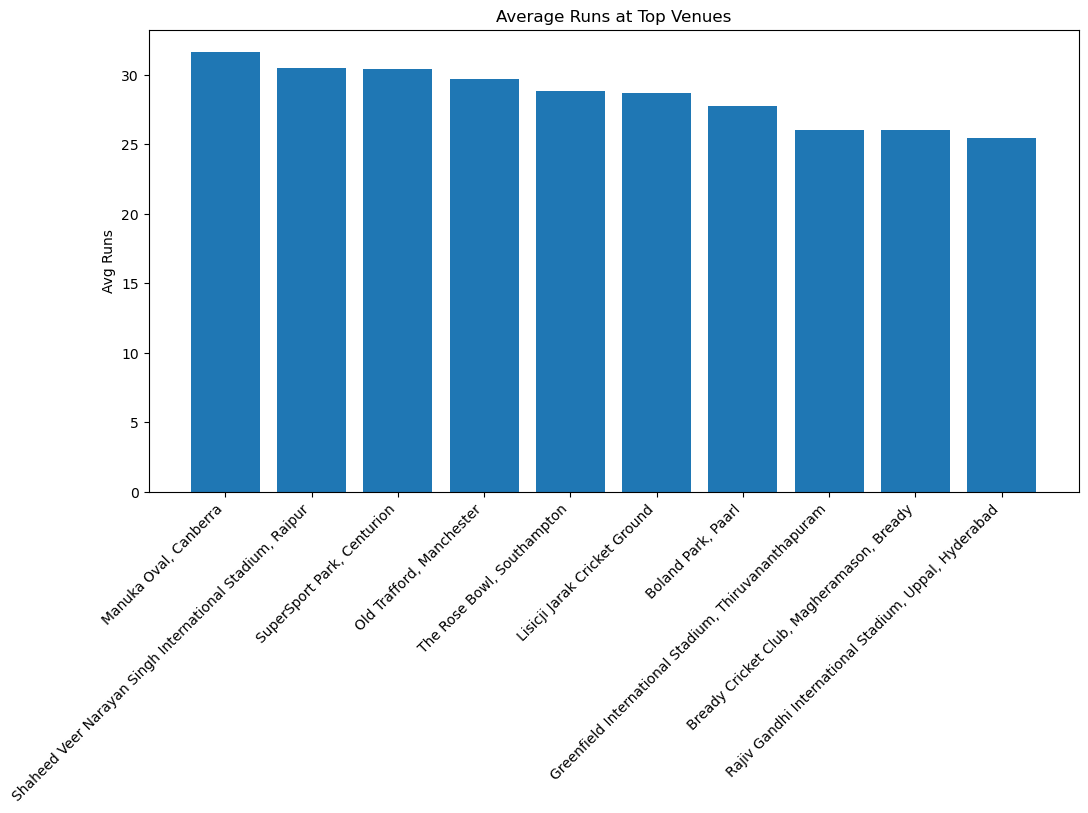

In [62]:
avg_runs_venue = (
    player_match_stats
    .groupby("venue")["runs"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
plt.bar(avg_runs_venue.index, avg_runs_venue.values)
plt.xticks(rotation=45, ha='right')
plt.title("Average Runs at Top Venues")
plt.ylabel("Avg Runs")
plt.show()

In [66]:
features = [
    "prev_runs",
    "prev_sr",
    "avg_last_3",
    "opponent_encoded",
    "venue_encoded",
    "pressure"
]